# Individual experiments

**Imports**

In [ ]:
# Navigate to appropriate directory
import sys
import os
sys.path.append(os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from time import time
from tqdm import tqdm

import patchmatch as pm
import postprocessing as pp

**Matplotlib display mode**

In [ ]:
# Run this cell to display matplotlib plots in a separate window
# %matplotlib qt

In [ ]:
# Run this cell to display matplotlib plots inside the jupyter notebook
# %matplotlib inline

In the following sections, we test the PatchMatch algorithm on 2 different images with copy-move forgery: one with a simple translation and one with a translation and a rotation.

## Some functions

In [ ]:
def plot_vect_field(pm_, mask, step=100, **kwargs):
    """
    Plot vect_field as arrows above the image
    
    Parameters
    ----------
    pm_ : instance of PatchMatch
    mask : array-like, shape (m, n)
        only vectors whose "roots" are on pixels for wich mask is non-zero will be plotted
    step : int
        step between two plotted vectors
    **kwargs : keyword arguments
        keyword arguments to be passed to plt.arrow (e.g. head_width, head_length, ...)
    """
    default_kwargs = {"width": 1e-3, "head_width": 1, "head_length": 1.5, "length_includes_head": True}
    default_kwargs.update(kwargs)
    default_kwargs["head_length"] = 1.5 * default_kwargs["head_width"]
    plt.imshow(pm_.im.astype("uint8"))
    for i in range(0, pm_.m, step):  # for each pixel in the mask
        for j in range(0, pm_.n, step):
            if mask[i, j] > 0:
                plt.arrow(j, i, *pm_.vect_field[i, j, ::-1], **default_kwargs)
    plt.axis("off")

## Image 1: Flowers

### Load image 

In [ ]:
im2 = Image.open("b.png")
im2 = np.array(im2).astype("double")
#gt2 = Image.open("data/CMFD_CODE/TP_C01_039_gt_r45.png")
#gt2 = np.array(gt2) > 0

### Initialize Patchmatch

In [ ]:
t0 = time()
a2 = pm.PatchMatch(
    im2,  # image
    p=10,  # patch half-size
    max_zrd=6,  # maximum Zernike degree
    min_dn=64,   # minimum displacement norm (previously T)
    n_rs_candidates=5,   # number of candidates in the random search phase (previously L)
    init_method=2,  # whether to use create_vect_field1 or create_vect_field2
    zernike=True  # whether to use Zernike moments
)
t1 = time()
print(t1 - t0)

### Run PatchMatch

In [ ]:
t0 = time()
a2.run(5)
t1 = time()
print(t1 - t0)

### Plot results

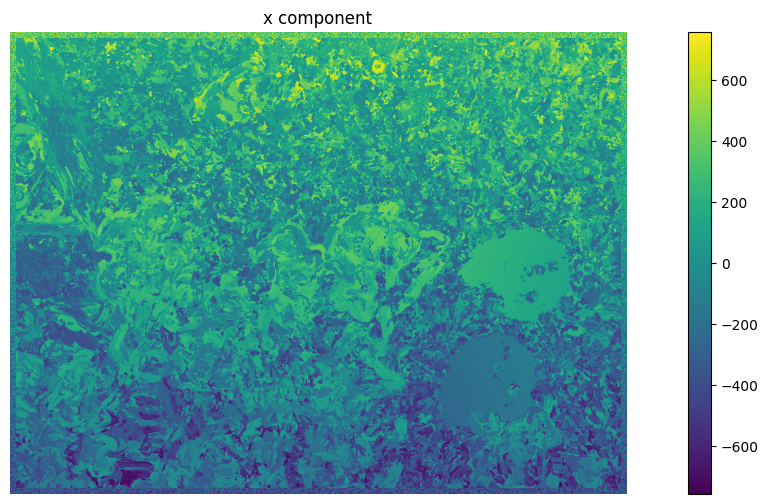

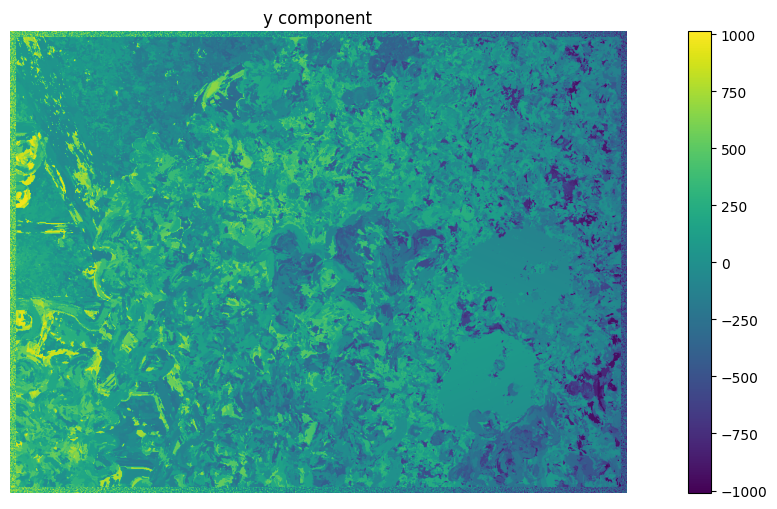

In [21]:
# x component
plt.figure(figsize=(16,6))
plt.title('x component')
plt.imshow(a2.vect_field[..., 0]) #, vmin=0, vmax=60)
plt.colorbar()
plt.axis("off")
plt.savefig("flowers_x_component.png",bbox_inches='tight',dpi=100)
plt.show()
# y component
plt.figure(figsize=(16,6))
plt.title('y component')
plt.imshow(a2.vect_field[..., 1]) #, vmin=0, vmax=60)
plt.colorbar()
plt.axis("off")
plt.savefig("flowers_y_component.png",bbox_inches='tight',dpi=100)
plt.show()

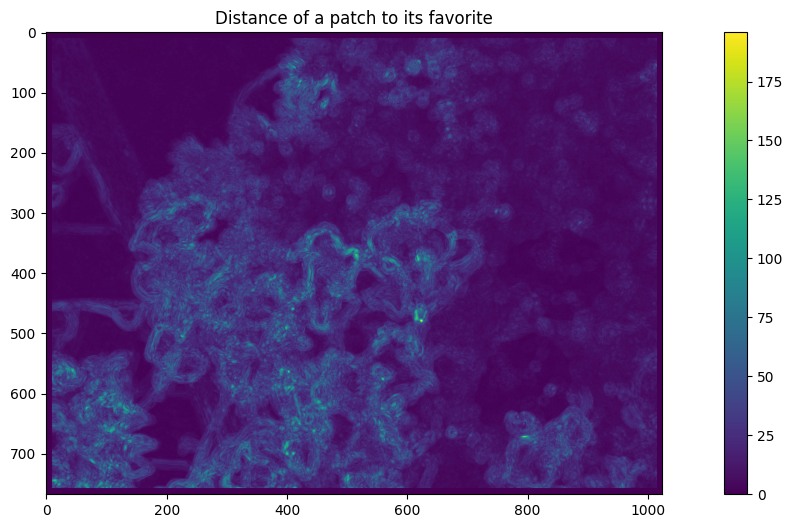

In [22]:
plt.figure(figsize=(16,6))
plt.title("Distance of a patch to its favorite")
plt.imshow(a2.dist_field)
plt.colorbar()
plt.show()

In [23]:
mask2 = pp.compute_mask_1(a2.vect_field, a2.m, a2.n, a2.p,128)

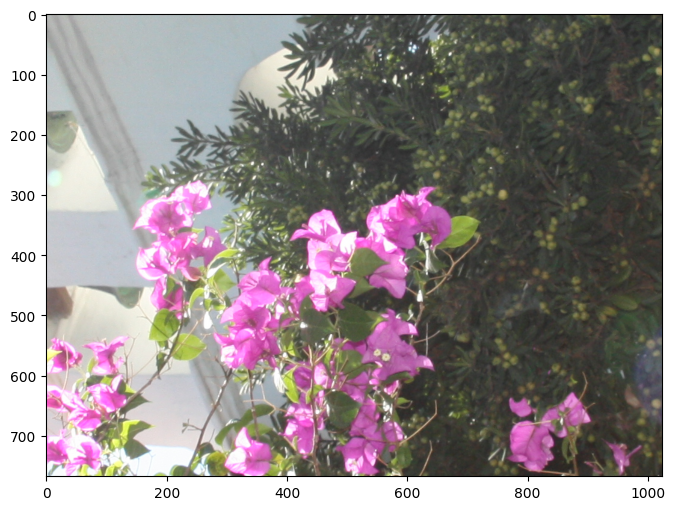

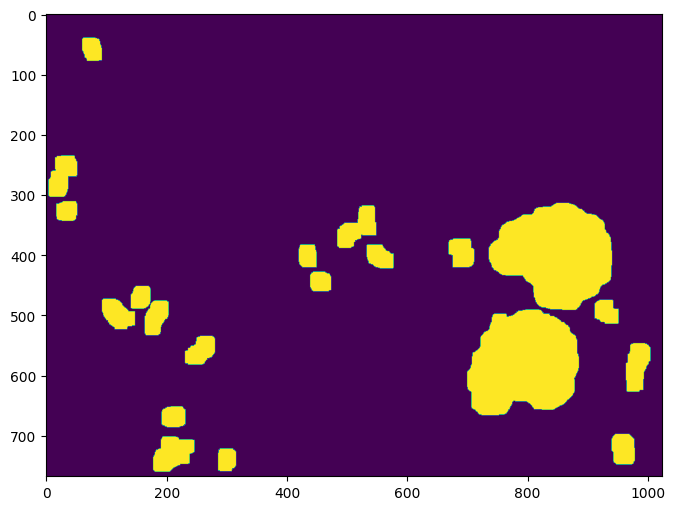

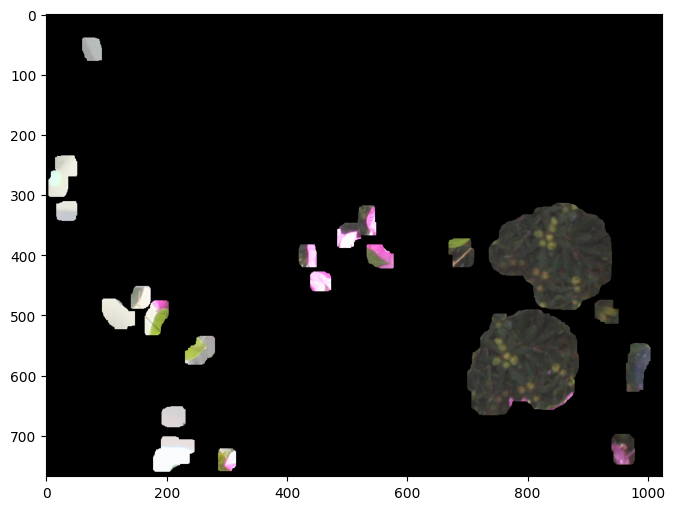

In [24]:
plt.figure(figsize=(16,6))
plt.imshow(im2.astype("uint8"))
plt.show()

plt.figure(figsize=(16,6))
plt.imshow(mask2)
plt.show()

plt.figure(figsize=(16,6))
plt.imshow((mask2[:,:,None]*im2).astype("uint8"))
plt.show()